# Вариант 1 
## Задание 1

Retention – один из самых важных показателей в компании. Ваша задача – написать функцию, которая будет считать retention игроков (по дням от даты регистрации игрока). Данные лежат в папке shared и имеют следующую структуру:

shared/problem1-reg_data.csv – данные о времени регистрации

shared/problem1-auth_data.csv – данные о времени захода пользователей в игру

In [11]:
import pandas as pd


In [2]:
# читаю файлы
reg_path = "/mnt/HC_Volume_18315164/home-jupyter/jupyter-nadezhda-birjukova-taw9579/shared/problem1-reg_data.csv"
auth_path = "/mnt/HC_Volume_18315164/home-jupyter/jupyter-nadezhda-birjukova-taw9579/shared/problem1-auth_data.csv"

reg_df = pd.read_csv(reg_path, sep=';')
auth_df = pd.read_csv(auth_path, sep=';')

In [3]:
def calculate_retention(reg_path, auth_path, user_sample=1000000, random_state=42):
    reg_df = pd.read_csv(reg_path, sep=';')
    auth_df = pd.read_csv(auth_path, sep=';')
    
    # Когда работу сдавала, все запускалось, но теперь - ни в какую не хочет. 
    # Пришлось все же семплить данные
    
    if user_sample:
        sampled_users = (reg_df['uid'].drop_duplicates()
                                      .sample(n=user_sample, random_state=random_state))
        
        reg_df = reg_df[reg_df['uid'].isin(sampled_users)]
        auth_df = auth_df[auth_df['uid'].isin(sampled_users)]

    reg_df['reg_date'] = pd.to_datetime(reg_df['reg_ts'], unit='s').dt.date
    auth_df['auth_date'] = pd.to_datetime(auth_df['auth_ts'], unit='s').dt.date

    df = auth_df.merge(reg_df[['uid', 'reg_date']], on='uid', how='inner')

    df['day_number'] = (df['auth_date'] - df['reg_date']).dt.days
    df = df[df['day_number'] <= 30]
    
    # Распределяем по когортам 
    df['cohort'] = df['reg_date']
    
    # считаю retention по когортам
    cohort_data = (
        df.groupby(['cohort', 'day_number'])['uid']
        .nunique()
        .reset_index(name='retained_users')
    )

    # считаю размер каждой когорты
    
    cohort_sizes = (
        reg_df.groupby('reg_date')['uid']
        .nunique()
        .reset_index(name='cohort_size')
    )
    
    # опционально доп.фильтр иначе получается слишком много NaN
    cohort_sizes = cohort_sizes[cohort_sizes['cohort_size'] >= 50]
            
    # объединяю результат
    retention = cohort_data.merge(cohort_sizes, left_on='cohort', right_on='reg_date')

    retention['retention'] = (retention['retained_users'] / retention['cohort_size'])       

    retention_matrix = retention.pivot(index='cohort', columns='day_number', values='retention')
        
    return retention_matrix  

In [13]:
result = calculate_retention(reg_path, auth_path, user_sample=500000)

In [14]:
result

day_number,0,1,2,3,4,5,6,7,8,9,...,21,22,23,24,25,26,27,28,29,30
cohort,,,,,,,,,,,,,,,,,,,,,
2015-09-10,1.0,0.019231,0.019231,0.057692,0.038462,0.096154,0.038462,0.057692,0.038462,0.057692,...,NaN,0.038462,0.019231,0.019231,NaN,0.038462,0.057692,0.019231,0.057692,0.019231
2015-11-24,1.0,NaN,0.080000,0.040000,NaN,0.060000,0.100000,0.060000,0.020000,0.040000,...,0.020000,NaN,0.080000,0.060000,0.080000,0.040000,0.020000,0.040000,0.020000,NaN
2015-11-29,1.0,0.020000,0.040000,0.060000,0.080000,0.080000,0.060000,0.060000,NaN,0.060000,...,0.040000,0.080000,0.020000,0.040000,0.020000,0.040000,0.040000,NaN,0.080000,0.040000
2015-12-05,1.0,0.019231,0.038462,0.057692,0.096154,0.057692,0.057692,0.076923,NaN,0.076923,...,0.076923,0.019231,0.038462,0.057692,0.057692,0.057692,0.019231,0.038462,0.019231,NaN
2015-12-08,1.0,0.019231,0.019231,0.057692,0.038462,0.076923,NaN,0.019231,0.038462,0.038462,...,0.038462,0.019231,0.019231,0.019231,0.038462,0.038462,0.038462,0.019231,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2020-09-19,1.0,0.017900,0.031026,0.046539,0.032220,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-20,1.0,0.018692,0.040888,0.026869,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-21,1.0,0.019182,0.025575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Задание 2

Имеются результаты A/B теста, в котором двум группам пользователей предлагались различные наборы акционных предложений. Известно, что ARPU в тестовой группе выше на 5%, чем в контрольной. При этом в контрольной группе 1928 игроков из 202103 оказались платящими, а в тестовой – 1805 из 202667.

Какой набор предложений можно считать лучшим? Какие метрики стоит проанализировать для принятия правильного решения и как?

В тексте указано, что ARPU в тестовой группе стал выше на 5%, т.е. в среднем с одного пользователя денег стало больше. Но конверсия в платящего складывается таким образом 1928 / 202 103 ≈ 0,95% (контрольная группа) и 1805 / 202 667 ≈ 0,89% (тестовая группа). Это показвает, что в тестовой группе меньше платящих пользователей, чем в контрольной. Т.е. меньше людей вообще решаются платить.

Метрика ARPU - это среднее по всем, и по тем, кто платит, и по тем, кто нет. Проще говоря мы видим примерно следующее: деньги выросли не потому, что стало больше покупателей,а потому что те, кто платят, стали платить больше.

По этим данным нельзя уверенно сказать, что тест лучше. Да, денег в среднем может стать больше (надо сравнить выручки). Но часть пользователей мы потеряли на этапе “решили ли они платить вообще”. Это создает риск, потому что сегодня ARPU вырос --> завтра станет меньше новых платящих --> через месяц упадёт общая выручка.

Итог: чтобы дать однозначный ответ нужно провести дополнительный анализ.

1. В какой группе в итоге заработали больше денег?
2. Нужно понять сильно ли вырос средний платёж в целом или рост ARPU - это эффект пары высокодоходных пользователей. Если платящих больше единицы, а остальные перестали - это плохой сигнал.
3. Насколько это вообще надёжный результат. Т.е. это реальный эффект или просто шум и случайность
4. По возможности проследить за пользователями после теста, если есть данные про повторные платежи и в целом про удержание

In [20]:
# Более подробно 

import pandas as pd
import numpy as np
import requests
import io
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from urllib.parse import urlencode
from statsmodels.stats.proportion import proportions_ztest

base_url = 'https://cloud-api.yandex.net/v1/disk/public/resources/download?'
# Сюда вписываете вашу ссылку:
public_key = 'https://disk.yandex.ru/d/SOkIsD5A8xlI7Q'

# Получаем загрузочную ссылку
final_url = base_url + urlencode(dict(public_key=public_key))
response = requests.get(final_url)
download_url = response.json()['href']

# Загружаем файл и читаем в датафрейм
download_response = requests.get(download_url)
df = pd.read_csv(io.BytesIO(download_response.content), sep=';')
df

# Данные взяты по совету 
# https://ru.stackoverflow.com/questions/1088300/как-скачивать-файлы-с-яндекс-диска

,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b
...,...,...,...
404765,404766,0,a
404766,404767,0,b
404767,404768,231,a
404768,404769,0,a


In [21]:
# Агрегируем данные

summary = df.groupby('testgroup')\
            .agg(users=('user_id', 'nunique'), 
                 revenue=('revenue', 'sum'), 
                 payers=('revenue', lambda x: (x > 0).sum()))\
            .reset_index()

In [22]:
# подготавливаем метрики для теста

summary['conversion'] = summary['payers'] / summary['users']
summary['ARPU'] = summary['revenue'] / summary['users']
summary['ARPPU'] = summary['revenue'] / summary['payers']

summary

,testgroup,users,revenue,payers,conversion,ARPU,ARPPU
0,a,202103,5136189,1928,0.009540,25.413720,2663.998444
1,b,202667,5421603,1805,0.008906,26.751287,3003.658172


In [23]:
# z-test

control = summary[summary.testgroup == 'a']
test = summary[summary.testgroup == 'b']

count = np.array([control['payers'].values[0], test['payers'].values[0]])
nobs = np.array([control['users'].values[0], test['users'].values[0]])

stat, p_value = proportions_ztest(count, nobs)

print("Z-stat:", stat)
print("P-value:", p_value)

Z-stat: 2.108028495889841
P-value: 0.035028524642854865


In [24]:
# Визуализация распределения ARPU

control_rev = df[df.testgroup == 'a']['revenue']
test_rev = df[df.testgroup == 'b']['revenue']

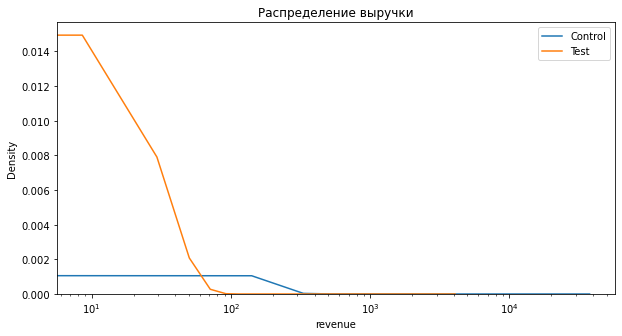

In [25]:
plt.figure(figsize=(10, 5))
sns.kdeplot(control_rev, label='Control')
sns.kdeplot(test_rev, label='Test')
plt.xscale('log')
plt.legend()
plt.title('Распределение выручки')
plt.show()

In [26]:
# ARPU распределён с сильным перекосом, поэтому t-test может быть некорректен. 
# При перекошенных данных бутстрэп даёт более надёжный вывод.

def bootstrap_mean_diff(group1, group2, n_boot=10000):
    diffs = []
    for _ in range(n_boot):
        sample1 = group1.sample(frac=1, replace=True)
        sample2 = group2.sample(frac=1, replace=True)
        diffs.append(sample2.mean() - sample1.mean())
    return np.array(diffs)

boot_diffs = bootstrap_mean_diff(control_rev, test_rev)

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)

print("95% CI:", ci_lower, ci_upper)

95% CI: -2.908915863452601 5.4814920711582245


In [27]:
# t-test

t_stat, p_val = stats.ttest_ind(
    control_rev,
    test_rev,
    equal_var=False
)

print("T-stat:", t_stat)
print("P-value:", p_val)

T-stat: -0.6234876562792212
P-value: 0.5329647014130866


In [31]:
# Статтест для ARPPU. Оставляем только платящих

control_ppu = df[(df.testgroup == 'a') & (df.revenue > 0)]['revenue']
test_ppu = df[(df.testgroup == 'b') & (df.revenue > 0)]['revenue']

In [32]:
# бутстрэп для нормального распределения

boot_diffs_ppu = bootstrap_mean_diff(control_ppu, test_ppu)

ci_lower = np.percentile(boot_diffs_ppu, 2.5)
ci_upper = np.percentile(boot_diffs_ppu, 97.5)

print("95% CI for ARPPU:", ci_lower, ci_upper)

95% CI for ARPPU: -77.4275992517329 735.956802263767


Теперь имея на руках данные по стат анализу можно говорить точнее. 

Мы имеем:

    Конверсия ↓ значимо (p < 0.05 - разница статистически значима. В тестовой группе снижается конверсия.)

    ARPU ↑ незначимо (t-test P-value: 0.533, Бутстрэп 95% CI: [-2.92 ; 5.50] - интервал включает 0 следовательно эффект не  значим. Рост ARPU статистически не подтверждён.)
    
    ARPPU ↑ незначимо (бутстрэп 95% CI: [-77.43 ; 735.96] - интервал включает 0 и имеет большой разброс. Разница среднего   чека платящих статистически не подтверждена и может быть вызвана высокой дисперсией или выбросами.)

    Общая выручка ↑ (Тестовая группа: 5 421 603
                     Контрольная группа: 5 136 189
                     Разница ≈ +285 000. 
                     При примерно равном количестве пользователей. То есть фактически тест принёс больше денег.)

Вывод: Тест уменьшил число платящих, но увеличил средний чек платящих за счёт этого суммарная выручка выше. В ходе анализа выявлено, что рост ARPU и ARPPU статистически не подтверждён - эффект неустойчивый и может объясняться высокой вариативностью платежей или влиянием отдельных крупных транзакций. Если цель бизнеса максимизация краткосрочной выручки - тест можно выкатывать. Если цель рост базы платящих и устойчивость - тест рискованный.

# Задание 3

В игре Plants & Gardens каждый месяц проводятся тематические события, ограниченные по времени. В них игроки могут получить уникальные предметы для сада и персонажей, дополнительные монеты или бонусы. Для получения награды требуется пройти ряд уровней за определенное время. С помощью каких метрик можно оценить результаты последнего прошедшего события?

Предположим, в другом событии мы усложнили механику событий так, что при каждой неудачной попытке выполнения уровня игрок будет откатываться на несколько уровней назад. Изменится ли набор метрик оценки результата? Если да, то как?

Вопрос 1. 

любые внутриигровые ивенты делаются для трех вещей:
1. удержать старых игроков 
2. привлечь новых игроков 
3. заработать 

соответственно метрики: 

- новые игроки; 

- игроки которые не играли и вернулись (reactivation); 
нужно определить период, после которого можно считать игрока вернувшимся, иначе не будет понятно от чего отталкиваться

- Остались ли они (вернувшиеся игроки) после окончания ивента?

- средний онлайн; 
важно: онлайн может колебаться времени суток, выходных и тд. Поэтому смотрим рост среднего онлайна по сравнению 
с аналогичным периодом без ивента

- сколько дней подряд игроки возвращались именно ради ивента
Позволяет понять «забежали и ушли» или ивент стал причиной ежедневного входа

- средняя длительность сессии и количество сессий в день
если они растут именно у участников ивента, значит контент удерживает внимание

- доход за период ивента; 
сравнивать с предыдущими ивентами и обычным периодом без ивента

- ARPU / ARPPU во время ивента (средний доход на игрока / на платящего игрока)
чтобы понять ивент заработал на большем числе платящих или за счет увеличения среднего чека

- Доля игроков ивента, которые совершили покупку купили ивентовые предметы;
актуально если есть ускорители, дополнительнык попытки, эксклюзивные предметы во внутреигровом магазине

Далее метрики для оценки качества ивента: 

- сколько наград получено;
Если награды не получают - ивент либо слишком сложный, либо неинтересный. Неинтересный/слишком сложный ивент - риск оттока 
игроков и снижение дохода в целом 

- сколько уровней пройдено и сколько попыток потрачено;
эту информацию нужно будет смотреть в связке с другими, чтобы оценить текущий ивент и заложить статистические данные в последующий   

- как быстро в среднем игроками был закрыт весь ивентовый контент

- доля игроков, которые дошли до конца ивента и получили финальную награду

- на каком уровне игроки чаще всего бросают ивент

Вопрос 2. 

Базовые метрики не меняются, но меняется их интерпретация и появляется необходимость в дополнительных метриках, связанных с фрустрацией и сложностью.

Новая механика резко повышает стоимость ошибки для игрока. значит есть риски фрустрации, потери интереса, оттока, негатива, падение рейтинга продукта.

Если доля игроков, которые дошли до конца ивента и получили финальную награду, сильно падает - это уже не «чуть сложнее», а наказание за ошибку. Т.е данная метрика становится более важной, т.к. становится критическим индикатором токсичности механики.

То, на каком уровне игроки чаще всего бросают ивент, становится ключевой метрикой. Особенно опасны точки «откат --> выход из игры --> не вернулся». Мониторим.

Количество попыток ранее - показатель челленджа. При новых правилах - показатель накапливаемой фрустрации. Важно смотреть не просто среднее число попыток, а попытки до первого выхода из ивента.

Средняя длительность сессии может искусственно вырасти из-за того, что игрок «застрял» из-за откатов, но это не равно вовлечённости. Метрику смотреть в совокупности с другими 

Новые метрики: 

- доля игроков, которые вышли из игры сразу после отката или не вернулись в ивент после неудачи

- сколько раз игрок проходит одни и те же уровни повторно из-за откатов